In [11]:
import json
import os
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

In [12]:
def read_json_file(file_path):
    with open(file_path, 'r') as file:
        return json.load(file)

In [4]:
def update_word_stats(word_stats: dict, entry):
    # entry is a whole cluster of ab xb ax xx
    
    for key in entry:
        processed_tokens = entry[key]["processed_tokens"]
        critical_surprisal = entry[key]["critical_surprisal"]
        
        unique_words = set(processed_tokens)  # avoid duplicates
        
        for word in unique_words:
            word_stats[word].append(critical_surprisal)  # store critical surprisal value

def calculate_statistics(word_stats: dict): # get stdev and mean for plotting purposes
    word_statistics = {}
    for word, values in word_stats.items():
        mean = np.mean(values)
        std_dev = np.std(values)
        word_statistics[word] = (mean, std_dev, len(values))
    return word_statistics

# a little bit of code duplication here
# analyze a folder as one unit
def itemwise_analyze_folder(folder_path):
    word_stats = defaultdict(list)
    
    for filename in os.listdir(folder_path):
        if filename.endswith(".json"):
            file_path = os.path.join(folder_path, filename)
            json_data = read_json_file(file_path)
            
            for entry in json_data:
                update_word_stats(word_stats, entry)
                
    word_statistics = calculate_statistics(word_stats)
    
    # sort by mean crit-surprisal
    sorted_word_stats = sorted(word_statistics.items(), key=lambda x: x[1][0], reverse=True)
    
    return sorted_word_stats

# analyze one json as one unit
def itemwise_analyze_json(file_path):
    word_stats = defaultdict(list)
    
    if file_path.endswith(".json"):
        json_data = read_json_file(file_path)
        
        for entry in json_data:
            update_word_stats(word_stats, entry)
            
    word_statistics = calculate_statistics(word_stats)
    
    # sort by mean crit-surprisal
    sorted_word_stats = sorted(word_statistics.items(), key=lambda x: x[1][0], reverse=True)
    
    return sorted_word_stats

In [15]:
def plot_word_stats(word_stats, title):
    # extract word and stats
    words = [word for word, _ in word_stats] # get word
    means = [mean for _, (mean, _, _) in word_stats] # get mean
    std_devs = [std_dev for _, (_, std_dev, _) in word_stats] # get stdev
    
    # standard plot w/ stdev bars
    plt.figure(figsize=(10, 6))
    plt.barh(words, means, color='skyblue', xerr=std_devs, capsize=2, error_kw={'linewidth': 0.5, 'alpha': 0.8})
    plt.xlabel('Mean Critical Surprisal')
    plt.ylabel('Words')
    plt.title(f'{title}: Words vs. Mean Critical Surprisal')
    
    plt.grid(True, axis='x', linestyle='--', linewidth=0.5, alpha=0.7)
    
    plt.tight_layout()
    plt.show()


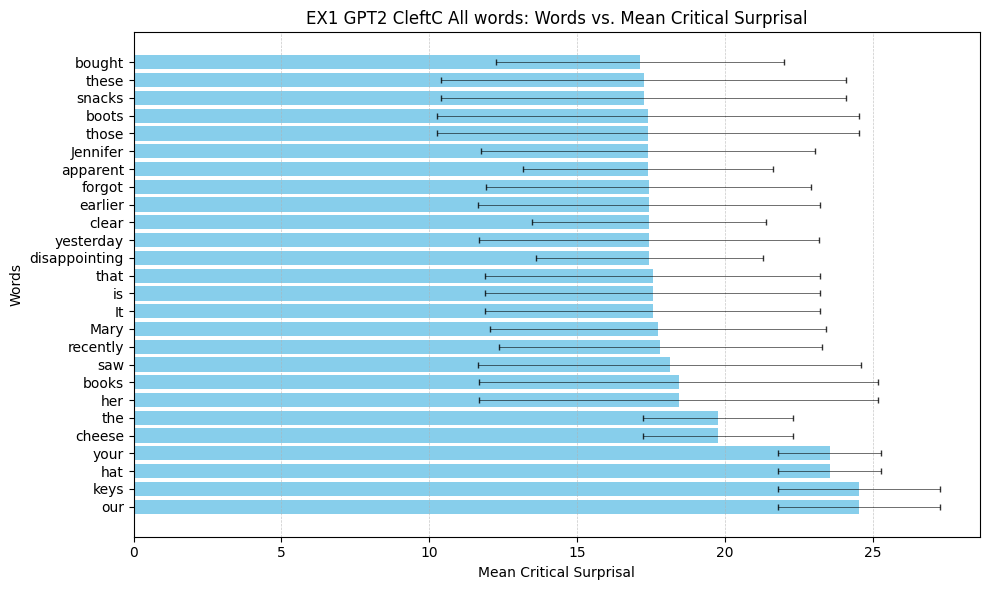

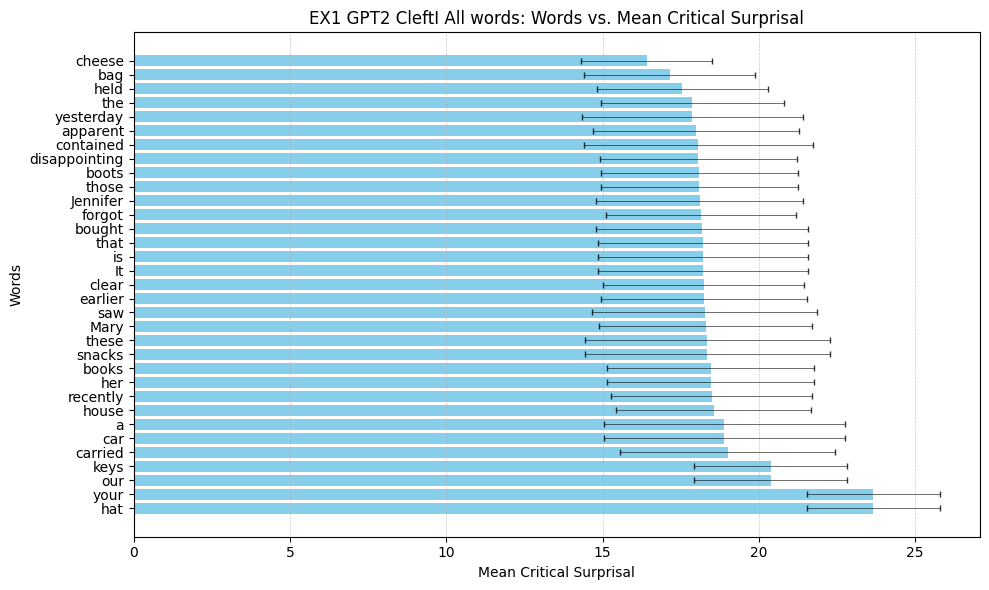

In [17]:
# two chosen arbitrarily as examples
plot_word_stats(itemwise_analyze_json("../grammar_outputs/experiment1/gpt2/cleft_grammar_c.json"), "EX1 GPT2 CleftC All words")
plot_word_stats(itemwise_analyze_json("../grammar_outputs/experiment1/gpt2/cleft_grammar_i.json"), "EX1 GPT2 CleftI All words")

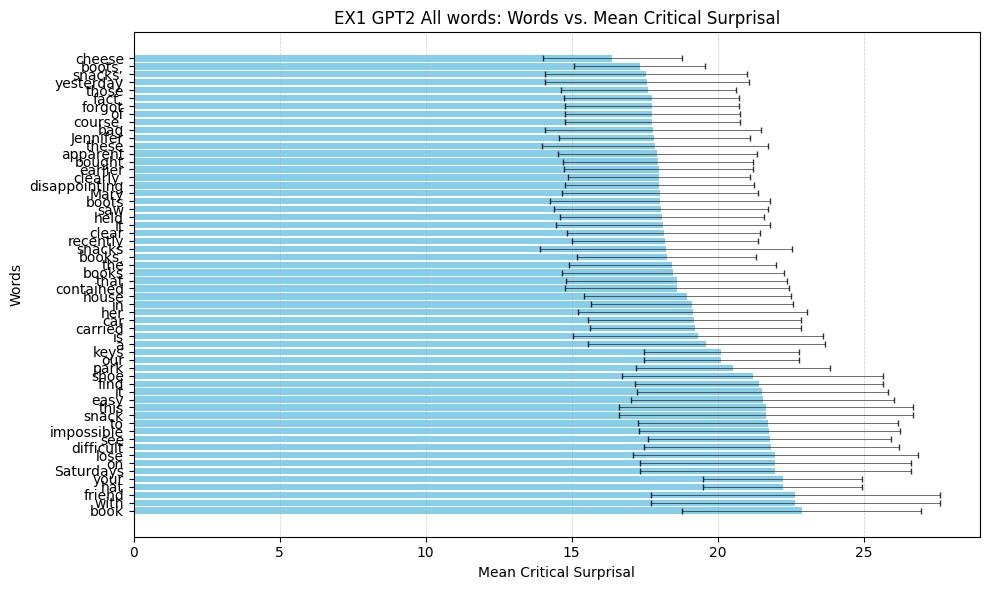

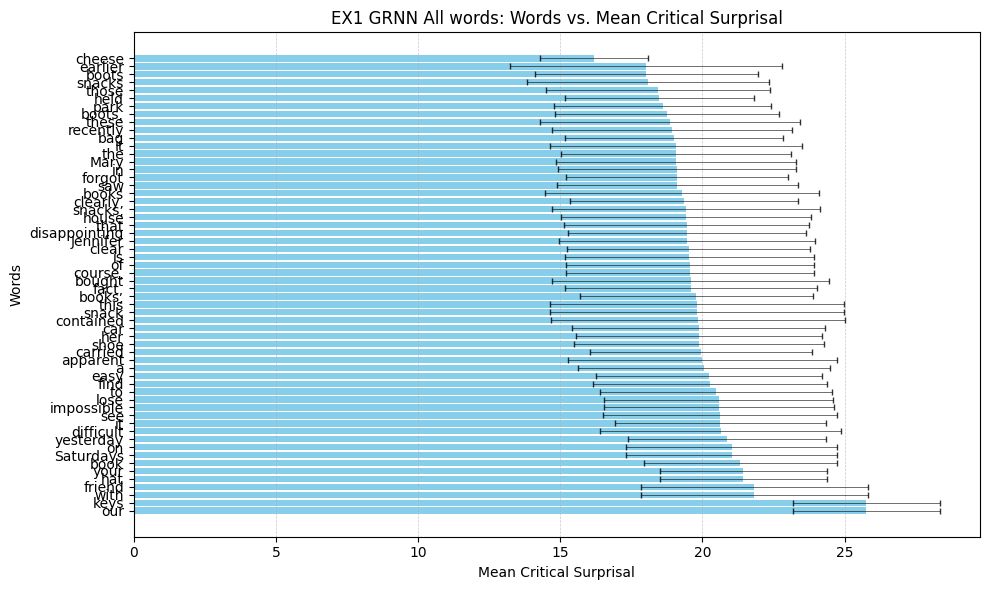

In [18]:
# again, chosen arbitrarily
# some words only appear in some jsons, so caution
plot_word_stats(itemwise_analyze_folder("../grammar_outputs/experiment1/gpt2/"), "EX1 GPT2 All words")
plot_word_stats(itemwise_analyze_folder("../grammar_outputs/experiment1/grnn/"), "EX1 GRNN All words")